Геном формы: [8, 7, 3, 0, 4, -9, -4, -8, 7, -2, 8, -7, -4, 2, 0, 7]
idx7 цели:   [1, 3, 6, 9, 10, 12, 15]
Одноцветный RGB: [49, 93, 84]
Разноцветный базовый RGB: [137, 185, 53]

ЧЁРНО-БЕЛАЯ БИОМОРФА
──────────────────────────────────────────────────
Поколений            │ 46
Chamfer Distance     │ 0.00
Fitness              │ 1.0000
IoU                  │ 1.0000
Гены совпали         │ ✓
Длина совпала        │ ✓
──────────────────────────────────────────────────


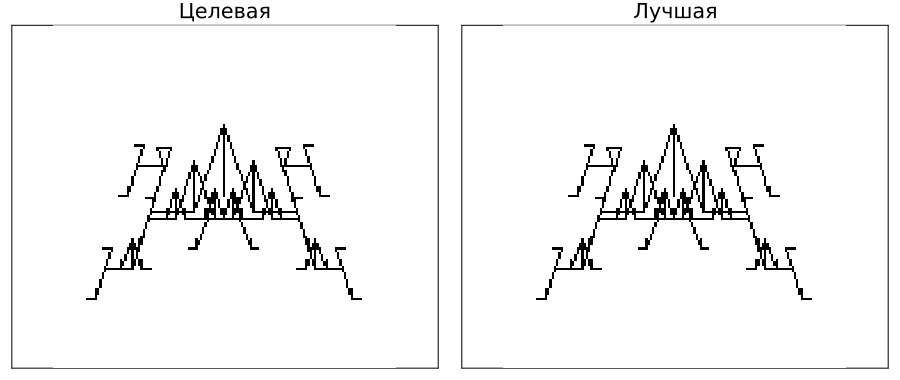

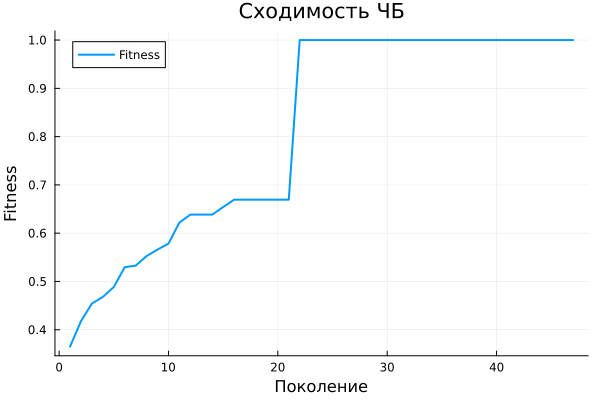


Последнее поколение:


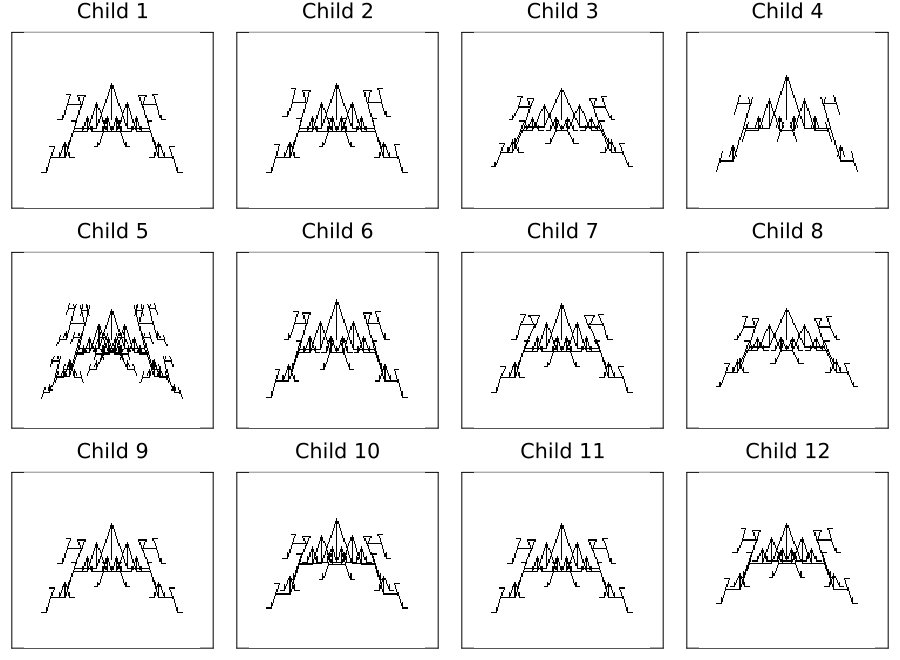


Эволюция:


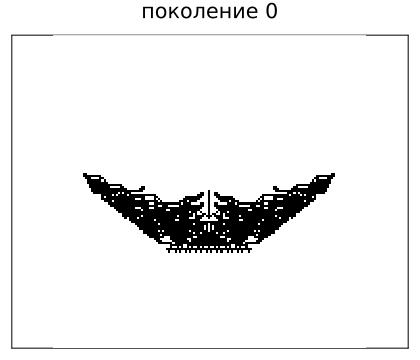


ОДНОЦВЕТНАЯ БИОМОРФА
──────────────────────────────────────────────────
Поколений            │ 141
Chamfer Distance     │ 0.00
Fitness              │ 1.0000
IoU                  │ 1.0000
Δ цвета              │ 0.0 ([49, 93, 84] → [49, 93, 84])
──────────────────────────────────────────────────


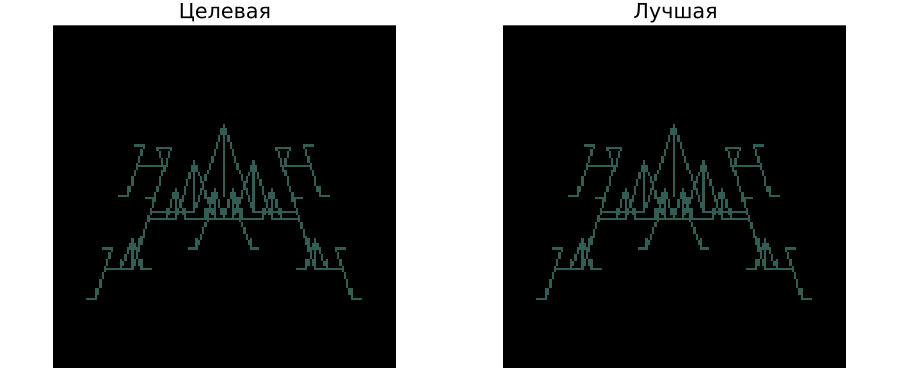

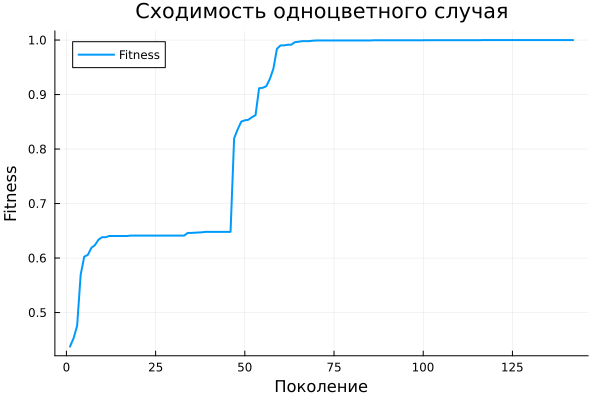


Эволюция:


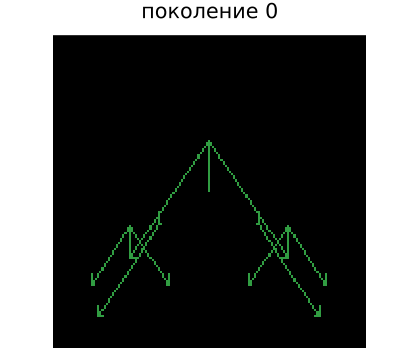


РАЗНОЦВЕТНАЯ БИОМОРФА
──────────────────────────────────────────────────
Поколений            │ 122
Chamfer Distance     │ 0.00
Fitness              │ 1.0000
IoU                  │ 1.0000
Δ цвета              │ 0.0 ([137, 185, 53] → [137, 185, 53])
──────────────────────────────────────────────────


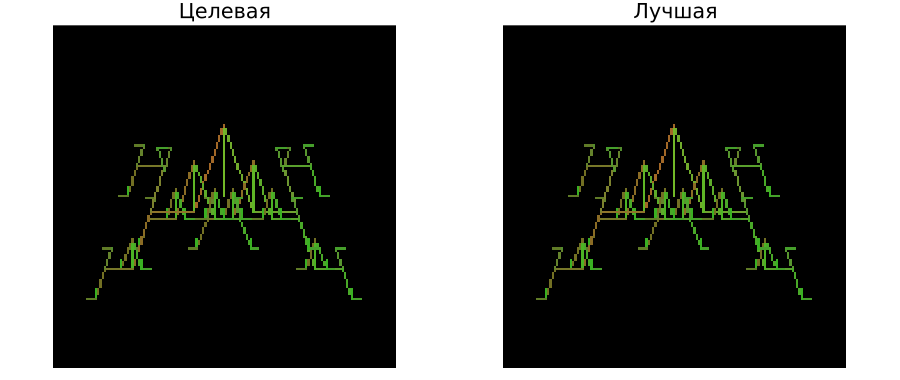

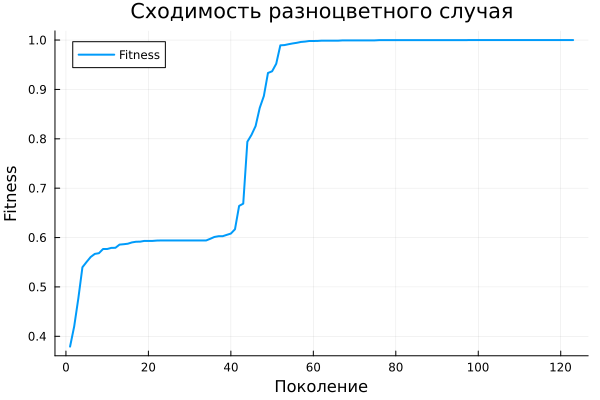


Эволюция:


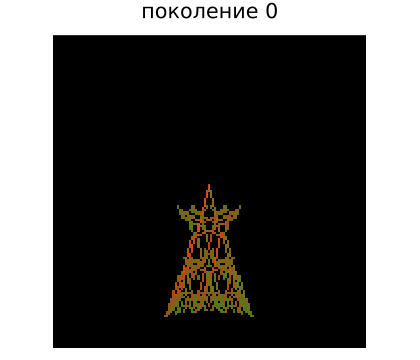

In [3]:
using Random
using Statistics
using Printf
using Logging
using Images
using ImageTransformations
using FileIO
using Plots

if Plots.backend() != Plots.GRBackend()
    gr()
end

const IMG_SIZE = 150
const GENE_MIN = -9
const GENE_MAX = 9
const LEN_GENE_MIN = 2
const LEN_GENE_MAX = 12
const COLOR_MIN = 0
const COLOR_MAX = 255

const N_CHILDREN_BW = 100
const N_CHILDREN_MONO = 100
const N_CHILDREN_MULTI = 100

const ELITE_SIZE = 6

const MAX_NO_IMPROVE_BW = 25
const MAX_NO_IMPROVE_MONO = 25
const MAX_NO_IMPROVE_MULTI = 25

const N_RESTARTS_BW = 6
const N_RESTARTS_MONO = 6
const N_RESTARTS_MULTI = 6

const MIN_IMPROVEMENT = 1e-4

const ANIMATION_FPS = 10
const ANIMATION_FINAL_HOLD = 8

const DIAG_MINABS = 2
const AXIS_SCALE = 0.9
const DIAG_SCALE = 1.15

safe_gene(v::Int) = v == 0 ? 1 : v

function random_genotype_bw()
    g = rand(GENE_MIN:GENE_MAX, 15)
    vcat(g, rand(LEN_GENE_MIN:LEN_GENE_MAX))
end

function random_genotype_mono()
    g = rand(GENE_MIN:GENE_MAX, 15)
    vcat(
        g,
        rand(LEN_GENE_MIN:LEN_GENE_MAX),
        rand(COLOR_MIN:COLOR_MAX),
        rand(COLOR_MIN:COLOR_MAX),
        rand(COLOR_MIN:COLOR_MAX),
    )
end

function random_genotype_multi()
    g = rand(GENE_MIN:GENE_MAX, 15)
    vcat(
        g,
        rand(LEN_GENE_MIN:LEN_GENE_MAX),
        rand(COLOR_MIN:COLOR_MAX),
        rand(COLOR_MIN:COLOR_MAX),
        rand(COLOR_MIN:COLOR_MAX),
    )
end

function mutate_shape_once!(g::Vector{Int}, idx7::Vector{Int}; fine::Bool=false)
    idx = rand(vcat(idx7, 16))
    if idx <= 15
        step = fine ? rand((-1, 1)) : rand((-3, -2, -1, 1, 2, 3))
        g[idx] = clamp(g[idx] + step, GENE_MIN, GENE_MAX)
    else
        step = fine ? rand((-1, 1)) : rand((-2, -1, 1, 2))
        g[idx] = clamp(g[idx] + step, LEN_GENE_MIN, LEN_GENE_MAX)
    end
end

function mutate_bw(genotype::Vector{Int}, idx7::Vector{Int}; fine::Bool=false)
    g = copy(genotype)
    mutate_shape_once!(g, idx7; fine=fine)
    if rand() < 0.25
        mutate_shape_once!(g, idx7; fine=fine)
    end
    g
end

function mutate_mono(genotype::Vector{Int}, idx7::Vector{Int}; fine::Bool=false)
    g = mutate_bw(genotype, idx7; fine=fine)

    ncolor = rand() < 0.4 ? 2 : 1
    for _ in 1:ncolor
        idx = rand(17:19)
        step = fine ? rand((-4, -3, -2, -1, 1, 2, 3, 4)) : rand((-24, -16, -12, -8, -4, 4, 8, 12, 16, 24))
        g[idx] = clamp(g[idx] + step, COLOR_MIN, COLOR_MAX)
    end

    g
end

function mutate_multi(genotype::Vector{Int}, idx7::Vector{Int}; fine::Bool=false)
    g = mutate_bw(genotype, idx7; fine=fine)

    ncolor = rand() < 0.5 ? 2 : 1
    for _ in 1:ncolor
        idx = rand(17:19)
        step = fine ? rand((-4, -3, -2, -1, 1, 2, 3, 4)) : rand((-24, -16, -12, -8, -4, 4, 8, 12, 16, 24))
        g[idx] = clamp(g[idx] + step, COLOR_MIN, COLOR_MAX)
    end

    g
end

function force_diag(x::Int, y::Int; minabs::Int=DIAG_MINABS)
    sx = x == 0 ? 1 : sign(x)
    sy = y == 0 ? 1 : sign(y)
    ax = max(abs(x), minabs)
    ay = max(abs(y), minabs)
    sx * ax, sy * ay
end

function calculate_stems(genes::Vector{Int})
    a1 = safe_gene(genes[1])
    a2 = safe_gene(genes[2])
    a3 = safe_gene(genes[3])
    a4 = safe_gene(genes[4])
    a5 = safe_gene(genes[5])
    a6 = safe_gene(genes[6])
    a7 = safe_gene(genes[7])

    ux, uy = force_diag(a2, a3; minabs=DIAG_MINABS)
    dx, dy = force_diag(a5, -a6; minabs=DIAG_MINABS)

    [
        (0.0, AXIS_SCALE * a1),
        (DIAG_SCALE * ux, DIAG_SCALE * uy),
        (AXIS_SCALE * a4, 0.0),
        (DIAG_SCALE * dx, DIAG_SCALE * dy),
        (0.0, -AXIS_SCALE * a7),
        (-DIAG_SCALE * dx, DIAG_SCALE * dy),
        (-AXIS_SCALE * a4, 0.0),
        (-DIAG_SCALE * ux, DIAG_SCALE * uy),
    ]
end

function render_segments(len::Int, stems; dir::Int=0, x::Float64=0.0, y::Float64=0.0, level::Int=1)
    newdir = mod(dir, 8) + 1
    dx, dy = stems[newdir]
    nx = x + len * dx
    ny = y + len * dy

    segs = [(x, y, nx, ny, level, newdir)]

    if len > 1
        append!(segs, render_segments(len - 1, stems; dir=dir + 1, x=nx, y=ny, level=level + 1))
        append!(segs, render_segments(len - 1, stems; dir=dir - 1, x=nx, y=ny, level=level + 1))
    end

    segs
end

function segment_bounds(segs)
    xs = Float64[]
    ys = Float64[]
    for (x1, y1, x2, y2) in segs
        push!(xs, x1, x2)
        push!(ys, y1, y2)
    end
    minimum(xs), maximum(xs), minimum(ys), maximum(ys)
end

function draw_line!(img::Matrix{Float64}, x0::Float64, y0::Float64, x1::Float64, y1::Float64; val::Float64=1.0)
    h, w = size(img)
    ix0, iy0 = round(Int, x0), round(Int, y0)
    ix1, iy1 = round(Int, x1), round(Int, y1)

    dx = abs(ix1 - ix0)
    dy = abs(iy1 - iy0)
    sx = ix0 < ix1 ? 1 : -1
    sy = iy0 < iy1 ? 1 : -1
    err = dx - dy
    x, y = ix0, iy0

    while true
        if 1 <= x <= w && 1 <= y <= h
            img[y, x] = val
        end
        (x == ix1 && y == iy1) && break
        e2 = 2 * err
        if e2 > -dy
            err -= dy
            x += sx
        end
        if e2 < dx
            err += dx
            y += sy
        end
    end
end

function genotype_to_image_bw(genotype::Vector{Int}; idx7::Vector{Int})::Matrix{Float64}
    vals7 = genotype[idx7]
    stems = calculate_stems(vals7)
    len = genotype[16]
    segs = render_segments(len, stems)

    coords = [(x1, y1, x2, y2) for (x1, y1, x2, y2, _, _) in segs]
    xmin, xmax, ymin, ymax = segment_bounds(coords)

    span = max(max(abs(xmin), abs(xmax)) * 2, max(abs(ymin), abs(ymax)) * 2, 1.0)
    scale = 120.0 / span
    cx, cy = IMG_SIZE / 2.0, IMG_SIZE / 2.0

    img = zeros(Float64, IMG_SIZE, IMG_SIZE)
    for (x1, y1, x2, y2, _, _) in segs
        draw_line!(img, cx + scale * x1, cy - scale * y1, cx + scale * x2, cy - scale * y2; val=1.0)
    end
    clamp.(img, 0.0, 1.0)
end

function genotype_to_image_mono(genotype::Vector{Int}; idx7::Vector{Int})::Array{Float64,3}
    vals7 = genotype[idx7]
    stems = calculate_stems(vals7)
    len = genotype[16]
    segs = render_segments(len, stems)

    coords = [(x1, y1, x2, y2) for (x1, y1, x2, y2, _, _) in segs]
    xmin, xmax, ymin, ymax = segment_bounds(coords)

    span = max(max(abs(xmin), abs(xmax)) * 2, max(abs(ymin), abs(ymax)) * 2, 1.0)
    scale = 120.0 / span
    cx, cy = IMG_SIZE / 2.0, IMG_SIZE / 2.0

    rv = genotype[17] / 255.0
    gv = genotype[18] / 255.0
    bv = genotype[19] / 255.0

    rimg = zeros(Float64, IMG_SIZE, IMG_SIZE)
    gimg = zeros(Float64, IMG_SIZE, IMG_SIZE)
    bimg = zeros(Float64, IMG_SIZE, IMG_SIZE)

    for (x1, y1, x2, y2, _, _) in segs
        px1, py1 = cx + scale * x1, cy - scale * y1
        px2, py2 = cx + scale * x2, cy - scale * y2
        draw_line!(rimg, px1, py1, px2, py2; val=rv)
        draw_line!(gimg, px1, py1, px2, py2; val=gv)
        draw_line!(bimg, px1, py1, px2, py2; val=bv)
    end

    cat(clamp.(rimg, 0.0, 1.0), clamp.(gimg, 0.0, 1.0), clamp.(bimg, 0.0, 1.0); dims=3)
end

function genotype_to_image_multi(genotype::Vector{Int}; idx7::Vector{Int})::Array{Float64,3}
    vals7 = genotype[idx7]
    stems = calculate_stems(vals7)
    len = genotype[16]
    segs = render_segments(len, stems)

    coords = [(x1, y1, x2, y2) for (x1, y1, x2, y2, _, _) in segs]
    xmin, xmax, ymin, ymax = segment_bounds(coords)

    span = max(max(abs(xmin), abs(xmax)) * 2, max(abs(ymin), abs(ymax)) * 2, 1.0)
    scale = 120.0 / span
    cx, cy = IMG_SIZE / 2.0, IMG_SIZE / 2.0

    base_r = genotype[17] / 255.0
    base_g = genotype[18] / 255.0
    base_b = genotype[19] / 255.0

    rimg = zeros(Float64, IMG_SIZE, IMG_SIZE)
    gimg = zeros(Float64, IMG_SIZE, IMG_SIZE)
    bimg = zeros(Float64, IMG_SIZE, IMG_SIZE)

    max_level = maximum(s[5] for s in segs)

    for (x1, y1, x2, y2, level, newdir) in segs
        px1, py1 = cx + scale * x1, cy - scale * y1
        px2, py2 = cx + scale * x2, cy - scale * y2

        t = max_level > 1 ? (level - 1) / (max_level - 1) : 0.0
        d = (newdir - 1) / 7.0

        rv = clamp(base_r * (0.55 + 0.45 * d) * (1.0 - 0.25 * t) + 0.15 * (1 - t), 0.0, 1.0)
        gv = clamp(base_g * (0.55 + 0.45 * (1 - d)) * (1.0 - 0.25 * t) + 0.15 * t, 0.0, 1.0)
        bv = clamp(base_b * (0.75 + 0.25 * sin(pi * d)) * (1.0 - 0.15 * t), 0.0, 1.0)

        draw_line!(rimg, px1, py1, px2, py2; val=rv)
        draw_line!(gimg, px1, py1, px2, py2; val=gv)
        draw_line!(bimg, px1, py1, px2, py2; val=bv)
    end

    cat(clamp.(rimg, 0.0, 1.0), clamp.(gimg, 0.0, 1.0), clamp.(bimg, 0.0, 1.0); dims=3)
end

function distance_transform(img::Matrix{Float64}; threshold::Float64=0.1)
    h, w = size(img)
    fg = img .> threshold

    if !any(fg)
        return fill(Float64(max(h, w)), h, w)
    end

    dist = fill(Inf, h, w)

    for i in 1:h, j in 1:w
        if fg[i, j]
            dist[i, j] = 0.0
        else
            if i > 1
                dist[i, j] = min(dist[i, j], dist[i - 1, j] + 1)
            end
            if j > 1
                dist[i, j] = min(dist[i, j], dist[i, j - 1] + 1)
            end
            if i > 1 && j > 1
                dist[i, j] = min(dist[i, j], dist[i - 1, j - 1] + 1.414)
            end
            if i > 1 && j < w
                dist[i, j] = min(dist[i, j], dist[i - 1, j + 1] + 1.414)
            end
        end
    end

    for i in h:-1:1, j in w:-1:1
        if !fg[i, j]
            if i < h
                dist[i, j] = min(dist[i, j], dist[i + 1, j] + 1)
            end
            if j < w
                dist[i, j] = min(dist[i, j], dist[i, j + 1] + 1)
            end
            if i < h && j < w
                dist[i, j] = min(dist[i, j], dist[i + 1, j + 1] + 1.414)
            end
            if i < h && j > 1
                dist[i, j] = min(dist[i, j], dist[i + 1, j - 1] + 1.414)
            end
        end
    end

    dist
end

function iou_score(img::Matrix{Float64}, target::Matrix{Float64}; threshold::Float64=0.1)
    a = img .> threshold
    b = target .> threshold
    inter = sum(a .& b)
    uni = sum(a .| b)
    uni == 0 ? 0.0 : inter / uni
end

function chamfer_distance(img::Matrix{Float64}, target::Matrix{Float64}, target_dt::Matrix{Float64}; threshold::Float64=0.1)
    fg_img = img .> threshold
    fg_target = target .> threshold

    n_img = sum(fg_img)
    n_target = sum(fg_target)

    (n_img == 0 || n_target == 0) && return Inf

    dist_img_to_target = sum(target_dt[fg_img]) / n_img
    img_dt = distance_transform(img; threshold=threshold)
    dist_target_to_img = sum(img_dt[fg_target]) / n_target

    (dist_img_to_target + dist_target_to_img) / 2
end

function fitness_bw(img::Matrix{Float64}, target::Matrix{Float64}, target_dt::Matrix{Float64})
    cd = chamfer_distance(img, target, target_dt)
    cd_score = 1.0 / (1.0 + cd / 8.0)

    fg_img = sum(img .> 0.1)
    fg_target = sum(target .> 0.1)
    size_ratio = min(fg_img, fg_target) / max(fg_img, fg_target, 1)

    overlap = iou_score(img, target)

    0.45 * cd_score + 0.15 * size_ratio + 0.40 * overlap
end

function color_match_score(img::Array{Float64,3}, target::Array{Float64,3}, mask::BitMatrix)
    sum(mask) <= 10 && return 0.0
    mae_r = mean(abs.(img[:, :, 1][mask] .- target[:, :, 1][mask]))
    mae_g = mean(abs.(img[:, :, 2][mask] .- target[:, :, 2][mask]))
    mae_b = mean(abs.(img[:, :, 3][mask] .- target[:, :, 3][mask]))
    1.0 - clamp(mean((mae_r, mae_g, mae_b)), 0.0, 1.0)
end

function fitness_color_mono(img::Array{Float64,3}, target::Array{Float64,3}, target_shape::Matrix{Float64}, target_dt::Matrix{Float64})
    img_shape = max.(img[:, :, 1], img[:, :, 2], img[:, :, 3])
    shape_score = fitness_bw(img_shape, target_shape, target_dt)

    target_mask = target_shape .> 0.01
    img_mask = img_shape .> 0.01
    common_mask = img_mask .& target_mask

    color_score = color_match_score(img, target, common_mask)

    0.85 * shape_score + 0.15 * color_score
end

function fitness_color_multi(img::Array{Float64,3}, target::Array{Float64,3}, target_shape::Matrix{Float64}, target_dt::Matrix{Float64})
    img_shape = max.(img[:, :, 1], img[:, :, 2], img[:, :, 3])
    shape_score = fitness_bw(img_shape, target_shape, target_dt)

    target_mask = target_shape .> 0.01
    img_mask = img_shape .> 0.01
    common_mask = img_mask .& target_mask

    color_score = color_match_score(img, target, common_mask)

    0.85 * shape_score + 0.15 * color_score
end

function topk_indices(v, k)
    p = sortperm(v; rev=true)
    p[1:min(k, length(p))]
end

function evolve_bw(target::Matrix{Float64}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_BW,
    max_no_improve::Int=MAX_NO_IMPROVE_BW)

    target_dt = distance_transform(target)

    population = [random_genotype_bw() for _ in 1:ELITE_SIZE]
    imgs = [genotype_to_image_bw(g; idx7=idx7) for g in population]
    fits = [fitness_bw(im, target, target_dt) for im in imgs]

    best_i = argmax(fits)
    best_geno = copy(population[best_i])
    best_img = copy(imgs[best_i])
    best_fit = fits[best_i]

    gen = 0
    no_imp = 0
    history = Float64[best_fit]
    img_hist = Matrix{Float64}[copy(best_img)]
    last_imgs = Matrix{Float64}[]

    while no_imp < max_no_improve
        gen += 1
        fine = no_imp > max_no_improve ÷ 2

        parents_idx = topk_indices(fits, ELITE_SIZE)
        parents = [population[i] for i in parents_idx]

        children = Vector{Vector{Int}}()
        for _ in 1:n_children
            p = parents[rand(1:length(parents))]
            push!(children, mutate_bw(p, idx7; fine=fine))
        end

        child_imgs = [genotype_to_image_bw(c; idx7=idx7) for c in children]
        child_fits = [fitness_bw(im, target, target_dt) for im in child_imgs]

        all_genos = vcat(parents, children)
        all_imgs = vcat([imgs[i] for i in parents_idx], child_imgs)
        all_fits = vcat([fits[i] for i in parents_idx], child_fits)

        elite_idx = topk_indices(all_fits, ELITE_SIZE)
        population = [copy(all_genos[i]) for i in elite_idx]
        imgs = [copy(all_imgs[i]) for i in elite_idx]
        fits = [all_fits[i] for i in elite_idx]

        last_imgs = child_imgs

        if fits[1] > best_fit + MIN_IMPROVEMENT
            best_fit = fits[1]
            best_geno = copy(population[1])
            best_img = copy(imgs[1])
            no_imp = 0
        else
            no_imp += 1
        end

        push!(history, best_fit)
        push!(img_hist, copy(best_img))
    end

    (
        best_genotype = best_geno,
        best_img = best_img,
        best_fit = best_fit,
        history = history,
        best_image_history = img_hist,
        last_child_images = last_imgs,
        generations = gen,
    )
end

function evolve_mono(target::Array{Float64,3}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_MONO,
    max_no_improve::Int=MAX_NO_IMPROVE_MONO)

    target_shape = max.(target[:, :, 1], target[:, :, 2], target[:, :, 3])
    target_dt = distance_transform(target_shape)

    population = [random_genotype_mono() for _ in 1:ELITE_SIZE]
    imgs = [genotype_to_image_mono(g; idx7=idx7) for g in population]
    fits = [fitness_color_mono(im, target, target_shape, target_dt) for im in imgs]

    best_i = argmax(fits)
    best_geno = copy(population[best_i])
    best_img = copy(imgs[best_i])
    best_fit = fits[best_i]

    gen = 0
    no_imp = 0
    history = Float64[best_fit]
    img_hist = Array{Float64,3}[copy(best_img)]

    while no_imp < max_no_improve
        gen += 1
        fine = no_imp > max_no_improve ÷ 2

        parents_idx = topk_indices(fits, ELITE_SIZE)
        parents = [population[i] for i in parents_idx]

        children = Vector{Vector{Int}}()
        for _ in 1:n_children
            p = parents[rand(1:length(parents))]
            push!(children, mutate_mono(p, idx7; fine=fine))
        end

        child_imgs = [genotype_to_image_mono(c; idx7=idx7) for c in children]
        child_fits = [fitness_color_mono(im, target, target_shape, target_dt) for im in child_imgs]

        all_genos = vcat(parents, children)
        all_imgs = vcat([imgs[i] for i in parents_idx], child_imgs)
        all_fits = vcat([fits[i] for i in parents_idx], child_fits)

        elite_idx = topk_indices(all_fits, ELITE_SIZE)
        population = [copy(all_genos[i]) for i in elite_idx]
        imgs = [copy(all_imgs[i]) for i in elite_idx]
        fits = [all_fits[i] for i in elite_idx]

        if fits[1] > best_fit + MIN_IMPROVEMENT
            best_fit = fits[1]
            best_geno = copy(population[1])
            best_img = copy(imgs[1])
            no_imp = 0
        else
            no_imp += 1
        end

        push!(history, best_fit)
        push!(img_hist, copy(best_img))
    end

    (
        best_genotype = best_geno,
        best_img = best_img,
        best_fit = best_fit,
        history = history,
        best_image_history = img_hist,
        last_child_images = Array{Float64,3}[],
        generations = gen,
    )
end

function evolve_multi(target::Array{Float64,3}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_MULTI,
    max_no_improve::Int=MAX_NO_IMPROVE_MULTI)

    target_shape = max.(target[:, :, 1], target[:, :, 2], target[:, :, 3])
    target_dt = distance_transform(target_shape)

    population = [random_genotype_multi() for _ in 1:ELITE_SIZE]
    imgs = [genotype_to_image_multi(g; idx7=idx7) for g in population]
    fits = [fitness_color_multi(im, target, target_shape, target_dt) for im in imgs]

    best_i = argmax(fits)
    best_geno = copy(population[best_i])
    best_img = copy(imgs[best_i])
    best_fit = fits[best_i]

    gen = 0
    no_imp = 0
    history = Float64[best_fit]
    img_hist = Array{Float64,3}[copy(best_img)]

    while no_imp < max_no_improve
        gen += 1
        fine = no_imp > max_no_improve ÷ 2

        parents_idx = topk_indices(fits, ELITE_SIZE)
        parents = [population[i] for i in parents_idx]

        children = Vector{Vector{Int}}()
        for _ in 1:n_children
            p = parents[rand(1:length(parents))]
            push!(children, mutate_multi(p, idx7; fine=fine))
        end

        child_imgs = [genotype_to_image_multi(c; idx7=idx7) for c in children]
        child_fits = [fitness_color_multi(im, target, target_shape, target_dt) for im in child_imgs]

        all_genos = vcat(parents, children)
        all_imgs = vcat([imgs[i] for i in parents_idx], child_imgs)
        all_fits = vcat([fits[i] for i in parents_idx], child_fits)

        elite_idx = topk_indices(all_fits, ELITE_SIZE)
        population = [copy(all_genos[i]) for i in elite_idx]
        imgs = [copy(all_imgs[i]) for i in elite_idx]
        fits = [all_fits[i] for i in elite_idx]

        if fits[1] > best_fit + MIN_IMPROVEMENT
            best_fit = fits[1]
            best_geno = copy(population[1])
            best_img = copy(imgs[1])
            no_imp = 0
        else
            no_imp += 1
        end

        push!(history, best_fit)
        push!(img_hist, copy(best_img))
    end

    (
        best_genotype = best_geno,
        best_img = best_img,
        best_fit = best_fit,
        history = history,
        best_image_history = img_hist,
        last_child_images = Array{Float64,3}[],
        generations = gen,
    )
end

function evolve_multi_start_bw(target::Matrix{Float64}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_BW,
    max_no_improve::Int=MAX_NO_IMPROVE_BW,
    n_restarts::Int=N_RESTARTS_BW)

    best = nothing
    best_fit = -Inf
    for _ in 1:n_restarts
        r = evolve_bw(target, idx7; n_children=n_children, max_no_improve=max_no_improve)
        if r.best_fit > best_fit
            best_fit = r.best_fit
            best = r
        end
    end
    best
end

function evolve_multi_start_mono(target::Array{Float64,3}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_MONO,
    max_no_improve::Int=MAX_NO_IMPROVE_MONO,
    n_restarts::Int=N_RESTARTS_MONO)

    best = nothing
    best_fit = -Inf
    for _ in 1:n_restarts
        r = evolve_mono(target, idx7; n_children=n_children, max_no_improve=max_no_improve)
        if r.best_fit > best_fit
            best_fit = r.best_fit
            best = r
        end
    end
    best
end

function evolve_multi_start_multi(target::Array{Float64,3}, idx7::Vector{Int};
    n_children::Int=N_CHILDREN_MULTI,
    max_no_improve::Int=MAX_NO_IMPROVE_MULTI,
    n_restarts::Int=N_RESTARTS_MULTI)

    best = nothing
    best_fit = -Inf
    for _ in 1:n_restarts
        r = evolve_multi(target, idx7; n_children=n_children, max_no_improve=max_no_improve)
        if r.best_fit > best_fit
            best_fit = r.best_fit
            best = r
        end
    end
    best
end

function show_bw(img::Matrix{Float64}, ttl::String)
    heatmap(
        img[end:-1:1, :],
        c=cgrad([:white, :black]),
        clims=(0, 1),
        aspect_ratio=1,
        colorbar=false,
        xticks=false,
        yticks=false,
        framestyle=:box,
        title=ttl
    )
end

function show_color(img::Array{Float64,3}, ttl::String)
    rgb = RGB.(img[:, :, 1], img[:, :, 2], img[:, :, 3])
    plot(rgb, axis=nothing, ticks=nothing, border=:none, title=ttl)
end

function show_children_gallery(child_imgs::Vector{Matrix{Float64}}; max_show::Int=12)
    k = min(length(child_imgs), max_show)
    ps = [show_bw(child_imgs[i], "Child $i") for i in 1:k]
    rows = ceil(Int, k / 4)
    cols = min(4, k)
    display(plot(ps..., layout=(rows, cols), size=(900, 220 * rows)))
end

function display_animation_bw(hist::Vector{Matrix{Float64}})
    frames = vcat(hist, fill(hist[end], ANIMATION_FINAL_HOLD))
    anim = Animation()
    for (i, img) in enumerate(frames)
        p = show_bw(img, "поколение $(min(i - 1, length(hist) - 1))")
        frame(anim, plot(p, size=(420, 360)))
    end
    tmp = tempname() * ".gif"
    with_logger(NullLogger()) do
        gif(anim, tmp, fps=ANIMATION_FPS)
    end
    display(MIME("image/gif"), read(tmp))
    rm(tmp; force=true)
end

function display_animation_color(hist::Vector{Array{Float64,3}})
    frames = vcat(hist, fill(hist[end], ANIMATION_FINAL_HOLD))
    anim = Animation()
    for (i, img) in enumerate(frames)
        p = show_color(img, "поколение $(min(i - 1, length(hist) - 1))")
        frame(anim, plot(p, size=(420, 360)))
    end
    tmp = tempname() * ".gif"
    with_logger(NullLogger()) do
        gif(anim, tmp, fps=ANIMATION_FPS)
    end
    display(MIME("image/gif"), read(tmp))
    rm(tmp; force=true)
end

function run_experiment_bw(target_img::Matrix{Float64}, idx7::Vector{Int}, target_genotype::Vector{Int})
    result = evolve_multi_start_bw(target_img, idx7)

    target_dt = distance_transform(target_img)
    cd = chamfer_distance(result.best_img, target_img, target_dt)
    overlap = iou_score(result.best_img, target_img)

    evolved_genes = result.best_genotype[idx7]
    target_genes = target_genotype[idx7]

    println("ЧЁРНО-БЕЛАЯ БИОМОРФА")
    println("─"^50)
    @printf("%-20s │ %d\n", "Поколений", result.generations)
    @printf("%-20s │ %.2f\n", "Chamfer Distance", cd)
    @printf("%-20s │ %.4f\n", "Fitness", result.best_fit)
    @printf("%-20s │ %.4f\n", "IoU", overlap)
    @printf("%-20s │ %s\n", "Гены совпали", evolved_genes == target_genes ? "✓" : "✗")
    @printf("%-20s │ %s\n", "Длина совпала", result.best_genotype[16] == target_genotype[16] ? "✓" : "✗")
    println("─"^50)

    display(plot(
        show_bw(target_img, "Целевая"),
        show_bw(result.best_img, "Лучшая"),
        layout=(1, 2),
        size=(900, 380)
    ))

    display(plot(result.history, lw=2, label="Fitness", xlabel="Поколение", ylabel="Fitness", title="Сходимость ЧБ"))

    println("\nПоследнее поколение:")
    show_children_gallery(result.last_child_images)

    println("\nЭволюция:")
    display_animation_bw(result.best_image_history)
    nothing
end

function run_experiment_mono(target_img::Array{Float64,3}, idx7::Vector{Int}, target_genotype::Vector{Int})
    result = evolve_multi_start_mono(target_img, idx7)

    target_shape = max.(target_img[:, :, 1], target_img[:, :, 2], target_img[:, :, 3])
    target_dt = distance_transform(target_shape)
    result_shape = max.(result.best_img[:, :, 1], result.best_img[:, :, 2], result.best_img[:, :, 3])

    cd = chamfer_distance(result_shape, target_shape, target_dt)
    overlap = iou_score(result_shape, target_shape)

    evolved_color = result.best_genotype[17:19]
    target_color = target_genotype[17:19]
    color_diff = sqrt(sum((evolved_color .- target_color) .^ 2))

    println("\nОДНОЦВЕТНАЯ БИОМОРФА")
    println("─"^50)
    @printf("%-20s │ %d\n", "Поколений", result.generations)
    @printf("%-20s │ %.2f\n", "Chamfer Distance", cd)
    @printf("%-20s │ %.4f\n", "Fitness", result.best_fit)
    @printf("%-20s │ %.4f\n", "IoU", overlap)
    @printf("%-20s │ %.1f (%s → %s)\n", "Δ цвета", color_diff, target_color, evolved_color)
    println("─"^50)

    display(plot(
        show_color(target_img, "Целевая"),
        show_color(result.best_img, "Лучшая"),
        layout=(1, 2),
        size=(900, 380)
    ))

    display(plot(result.history, lw=2, label="Fitness", xlabel="Поколение", ylabel="Fitness", title="Сходимость одноцветного случая"))

    println("\nЭволюция:")
    display_animation_color(result.best_image_history)
    nothing
end

function run_experiment_multi(target_img::Array{Float64,3}, idx7::Vector{Int}, target_genotype::Vector{Int})
    result = evolve_multi_start_multi(target_img, idx7)

    target_shape = max.(target_img[:, :, 1], target_img[:, :, 2], target_img[:, :, 3])
    target_dt = distance_transform(target_shape)
    result_shape = max.(result.best_img[:, :, 1], result.best_img[:, :, 2], result.best_img[:, :, 3])

    cd = chamfer_distance(result_shape, target_shape, target_dt)
    overlap = iou_score(result_shape, target_shape)

    evolved_color = result.best_genotype[17:19]
    target_color = target_genotype[17:19]
    color_diff = sqrt(sum((evolved_color .- target_color) .^ 2))

    println("\nРАЗНОЦВЕТНАЯ БИОМОРФА")
    println("─"^50)
    @printf("%-20s │ %d\n", "Поколений", result.generations)
    @printf("%-20s │ %.2f\n", "Chamfer Distance", cd)
    @printf("%-20s │ %.4f\n", "Fitness", result.best_fit)
    @printf("%-20s │ %.4f\n", "IoU", overlap)
    @printf("%-20s │ %.1f (%s → %s)\n", "Δ цвета", color_diff, target_color, evolved_color)
    println("─"^50)

    display(plot(
        show_color(target_img, "Целевая"),
        show_color(result.best_img, "Лучшая"),
        layout=(1, 2),
        size=(900, 380)
    ))

    display(plot(result.history, lw=2, label="Fitness", xlabel="Поколение", ylabel="Fitness", title="Сходимость разноцветного случая"))

    println("\nЭволюция:")
    display_animation_color(result.best_image_history)
    nothing
end

function run_experiment(target_source=nothing)
    if target_source === nothing
        idx7_target = sort(randperm(15)[1:7])

        shape_genome = random_genotype_bw()

        mono_genome = random_genotype_mono()
        mono_genome[1:16] = shape_genome

        multi_genome = random_genotype_multi()
        multi_genome[1:16] = shape_genome

        target_bw = genotype_to_image_bw(shape_genome; idx7=idx7_target)
        target_mono = genotype_to_image_mono(mono_genome; idx7=idx7_target)
        target_multi = genotype_to_image_multi(multi_genome; idx7=idx7_target)

        println("Геном формы: ", shape_genome)
        println("idx7 цели:   ", idx7_target)
        println("Одноцветный RGB: ", mono_genome[17:19])
        println("Разноцветный базовый RGB: ", multi_genome[17:19])
        println()

        run_experiment_bw(target_bw, idx7_target, shape_genome)
        run_experiment_mono(target_mono, idx7_target, mono_genome)
        run_experiment_multi(target_multi, idx7_target, multi_genome)
    else
        idx7_search = sort(randperm(15)[1:7])

        target_bw = preprocess_silhouette_bw(target_source)
        target_color = preprocess_silhouette_color(target_source)

        dummy_bw = zeros(Int, 16)

        println("Целевое: $target_source")
        println("idx7 поиска: ", idx7_search)

        run_experiment_bw(target_bw, idx7_search, dummy_bw)
    end
    nothing
end

run_experiment()
# run_experiment("evolution_images/butterfly.jpg")